In [1]:
import os
import sys
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
from daaq.utils.plot_tools import setupax_2dmap, make_panels, add_colorbar
from daaq.obs_utils.ioda_tools import IODAFile
from daaq.utils.date_tools import get_dates

In [2]:
sdate = 2024110100
edate = 2024113018
date_interval = 6
dates = get_dates(sdate, edate, date_interval)

savefig = False
save_quality = 600  # dpi
savefig_dir = "/glade/work/swei/projects/mmm.pace_aod/repos/Visualization/output/test"

ioda_path = '/glade/campaign/ncar/nmmm0072/Data/obs_pandac'

# Define the dictionary for IODA obs name and the select channel indice list (from 0), use None for all channels
obs_name_chidx_dict = {
    'oci_uaa_pace_aod': [3],
    # 'spexone_remotap_pace_aod': [7],
    # 'spexone_fmapol_pace_aod': [22],
    # 'harp2_fmapol_pace_aod': [1],
    # 'modis_terra_aod': [0], 
    'modis_aqua_aod': [0],
    # 'viirs_aod_dt_npp': [0], 
    # 'viirs_aod_dt_n20': [0],
    # 'viirs_aod_db_npp': [0], 
    'viirs_aod_db_n20': [0],
}

In [3]:
# load multiple IODA files with cycle column
multi_dfs = {}
channel_metas = {}
for prod, selchidx in obs_name_chidx_dict.items():
    print(f'Load {prod}')
    obs_files = []
    avail_dates = []
    for date in dates:
        cdate_str = date.strftime("%Y%m%d%H")
        obs_file = f"{ioda_path}/{prod}/{cdate_str}/{prod}_obs_{cdate_str}.h5"
        if os.path.exists(obs_file):
            obs_files.append(obs_file)
            avail_dates.append(date)
    multi_dfs[prod], channel_metas[prod] = IODAFile.concat(obs_files, channel_index=selchidx, cycles=avail_dates)
    print(f'  counts= {len(multi_dfs[prod])}')

print(multi_dfs.keys())
multi_dfs['oci_uaa_pace_aod']

Load oci_uaa_pace_aod
  counts= 24066468
Load modis_aqua_aod
  counts= 16833722
Load viirs_aod_db_n20
  counts= 72456679
dict_keys(['oci_uaa_pace_aod', 'modis_aqua_aod', 'viirs_aod_db_n20'])


,dateTime,latitude,longitude,surfaceQualifier,ObsError_aerosolOpticalDepth_3,ObsValue_aerosolOpticalDepth_3,PreQC_aerosolOpticalDepth_3,cycle
0,2024-10-31 21:58:02+00:00,-74.445419,-105.937378,0,0.06125,0.075,2,2024-11-01 00:00:00
1,2024-10-31 21:58:02+00:00,-74.408272,-105.701462,0,0.06110,0.074,2,2024-11-01 00:00:00
2,2024-10-31 21:58:02+00:00,-74.454376,-106.554688,0,0.06350,0.090,2,2024-11-01 00:00:00
3,2024-10-31 21:58:02+00:00,-74.417686,-106.316528,0,0.06215,0.081,2,2024-11-01 00:00:00
4,2024-10-31 21:58:02+00:00,-74.380814,-106.079865,0,0.06065,0.071,2,2024-11-01 00:00:00
...,...,...,...,...,...,...,...,...
24066463,2024-11-30 20:05:07+00:00,57.894463,-119.246552,1,0.32180,1.359,0,2024-11-30 18:00:00
24066464,2024-11-30 20:05:07+00:00,58.010235,-119.033432,1,0.57640,2.632,0,2024-11-30 18:00:00
24066465,2024-11-30 20:05:07+00:00,55.623665,-132.586304,1,0.06200,0.060,0,2024-11-30 18:00:00
24066466,2024-11-30 20:05:07+00:00,55.690346,-132.652328,1,0.06540,0.077,0,2024-11-30 18:00:00


Plotting: oci_uaa_pace_aod
  counts= 887199
Plotting: modis_aqua_aod
  counts= 613732
Plotting: viirs_aod_db_n20
  counts= 2729066


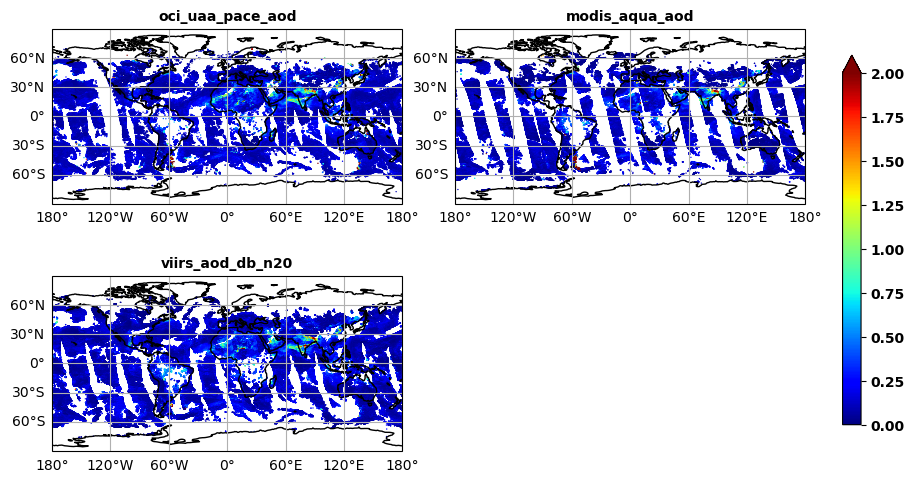

In [ ]:
plotgrp = 'ObsValue'
plotvar = 'aerosolOpticalDepth'
plotdates = dates[:4]

fig, axes = make_panels(obs_name_chidx_dict.keys(), ncols=2, panel_size=(6, 3), projection=ccrs.PlateCarree(), wspace=0.15, hspace=0.15)

for (prod, chidx), ax in zip(obs_name_chidx_dict.items(), axes):
    print(f'Plotting: {prod}')
    channel_meta = channel_metas[prod]
    plot_df = multi_dfs[prod].loc[multi_dfs[prod]['cycle'].isin(plotdates)]
    print(f'  counts= {len(plot_df)}')
    plot_col = f'{plotgrp}_{plotvar}_{chidx[0]}'
    if not channel_meta:
        titlestr = f'{plotvar} {plotgrp} at 0.55 um'
    else:
        titlestr = f'{plotvar} {plotgrp} at {channel_meta['sensorCentralWavelength'][chidx[0]]:.3f} um'

    _, ax, gl = setupax_2dmap(ax=ax, cornerlatlon=None, gl_lbsize=10)
    sc = ax.scatter(
        plot_df['longitude'],
        plot_df['latitude'],
        c=plot_df[plot_col],
        s=1,
        cmap='jet',
        vmin=0.,
        vmax=2.,
        edgecolors="None",
    )
    ax.set_title(prod, fontweight='bold', fontsize=10)
add_colorbar(fig, axes, sc, cbar_label_weight='bold', cbar_tick_weight='bold')

if savefig:
    if not os.path.exists(savefig_dir):
        os.makedirs(savefig_dir)
    figname = f'{savefig_dir}/test.png'
    fig.savefig(figname, dpi=save_quality, bbox_inches='tight')